# Simplest CRNN for Polish phoneme windows

- Mel spectrogram as input
- Classification window: **50 ms**, shift: **20 ms**
- Label for each window = **vowel with the largest time overlap** in that window; `non_vowel` if no vowel is present.
- Spectrogram hop = **10 ms** (so 1 window = 5 spectrogram frames, shift = 2 frames).

In [1]:
import os, glob
import numpy as np
import torch
import torch.nn as nn
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.io import wavfile

# ---- spectrogram config ----
SAMPLE_RATE = 16000
N_FFT       = 400            # 25 ms
HOP_LENGTH  = 160            # 10 ms   -> 1 spec frame = 10 ms
N_MELS      = 128

# ---- classification window ----
WIN_MS       = 50
SHIFT_MS     = 10
FRAME_MS     = HOP_LENGTH * 1000 // SAMPLE_RATE        # 10
WIN_FRAMES   = WIN_MS   // FRAME_MS                    # 5
SHIFT_FRAMES = SHIFT_MS // FRAME_MS                    # 2
print(f'window = {WIN_FRAMES} frames, shift = {SHIFT_FRAMES} frames')

# ---- labels: Polish vowels + non_vowel ----
VOWELS    = [
    'S', 'Z', 'a', 'b', 'c', 'd', 'dZ', 'dz', 'dzj', 'e', 'eo5', 'f', 'g',
    'h', 'i', 'i2', 'j', 'k', 'l', 'm', 'n', 'n~', 'o', 'oc5', 'p', 'r',
    's', 'sil', 'sj', 'sp', 't', 'tS', 'tsj', 'u', 'v', 'w', 'y', 'z', 'zj',
]
NON_VOWEL = 'non_vowel'
LABELS    = VOWELS + [NON_VOWEL]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for l, i in LABEL2IDX.items()}
N_CLASSES = len(LABELS)
print('classes:', LABELS)

window = 5 frames, shift = 1 frames
classes: ['S', 'Z', 'a', 'b', 'c', 'd', 'dZ', 'dz', 'dzj', 'e', 'eo5', 'f', 'g', 'h', 'i', 'i2', 'j', 'k', 'l', 'm', 'n', 'n~', 'o', 'oc5', 'p', 'r', 's', 'sil', 'sj', 'sp', 't', 'tS', 'tsj', 'u', 'v', 'w', 'y', 'z', 'zj', 'non_vowel']


## TextGrid parser (same as in the exploration notebook)

In [2]:
def parse_phonemes(text_grid):
    """Return list of (xmin, xmax, text) from the 'phones' tier."""
    phonemes = []
    in_phones = False
    xmin = xmax = None
    for line in text_grid.split('\n'):
        line = line.strip()
        if 'name = "phones"' in line:
            in_phones = True; continue
        if in_phones and line.startswith('name =') and 'phones' not in line:
            break
        if not in_phones:
            continue
        if line.startswith('xmin =') and 'intervals' not in line:
            xmin = float(line.split('=')[1].strip())
        elif line.startswith('xmax =') and 'intervals' not in line:
            xmax = float(line.split('=')[1].strip())
        elif line.startswith('text ='):
            text = line.split('=', 1)[1].strip().strip('"')
            if xmin is not None and xmax is not None:
                phonemes.append((xmin, xmax, text))
            xmin = xmax = None
    return phonemes

## Mel spectrogram + windowing with dominant-vowel labels

In [3]:
mel_tf = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT,
                          hop_length=HOP_LENGTH, n_mels=N_MELS)
db_tf  = T.AmplitudeToDB()

def wav_to_logmel(wav_path):
    sr, audio = wavfile.read(wav_path)
    assert sr == SAMPLE_RATE, f'expected {SAMPLE_RATE} Hz, got {sr}'
    if np.issubdtype(audio.dtype, np.integer):
        audio = audio.astype(np.float32) / np.iinfo(audio.dtype).max
    else:
        audio = audio.astype(np.float32)
    wav = torch.from_numpy(audio).unsqueeze(0)  # (1, n_samples)
    mel = db_tf(mel_tf(wav)).squeeze(0)         # (n_mels, T)
    return mel


def windows_and_labels(mel, phonemes):
    """Slide a 50 ms window with 20 ms shift over the mel spectrogram.
    For each window pick the vowel with the largest overlap; else non_vowel.
    Returns a list of (window_tensor, label_idx)."""
    n_mels, T = mel.shape
    frame_dur = HOP_LENGTH / SAMPLE_RATE  # seconds per frame
    out = []
    for start in range(0, T - WIN_FRAMES + 1, SHIFT_FRAMES):
        end = start + WIN_FRAMES
        t_start = start * frame_dur
        t_end   = end   * frame_dur
        best_vowel, best_overlap = None, 0.0
        for (pmin, pmax, ptext) in phonemes:
            if ptext not in VOWELS:
                continue
            overlap = min(pmax, t_end) - max(pmin, t_start)
            if overlap > best_overlap:
                best_overlap, best_vowel = overlap, ptext
        label = best_vowel if best_vowel is not None else NON_VOWEL
        out.append((mel[:, start:end].clone(), LABEL2IDX[label]))
    return out

c:\Users\mmapa\Desktop\Eti\ASR\ASR_project\.venv\Lib\site-packages\torchaudio\functional\functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


## Dataset — scans a directory for paired `.wav` + `.TextGrid` files

In [4]:
from pathlib import Path

class PhonemeWindowDataset(Dataset):
    def __init__(self, data_dir, max_files=None, verbose=True):
        # recursively find every .TextGrid at any depth under data_dir
        tg_paths = sorted(str(p) for p in Path(data_dir).rglob('*.TextGrid'))
        if verbose:
            print(f'found {len(tg_paths)} TextGrid files under {data_dir}')
        if max_files is not None:
            tg_paths = tg_paths[:max_files]
        xs, ys = [], []
        for i, tg in enumerate(tg_paths):
            wav = tg[:-len('.TextGrid')] + '.wav'
            if not os.path.exists(wav):
                continue
            try:
                mel = wav_to_logmel(wav)
                with open(tg, 'r', encoding='utf-8') as f:
                    phonemes = parse_phonemes(f.read())
                for w, lbl in windows_and_labels(mel, phonemes):
                    xs.append(w); ys.append(lbl)
            except Exception as e:
                if verbose: print(f'skip {tg}: {e}')
            if verbose and (i + 1) % 100 == 0:
                print(f'  processed {i+1}/{len(tg_paths)} files, {len(xs)} windows')
        self.X = torch.stack(xs) if xs else torch.empty(0, N_MELS, WIN_FRAMES)
        self.y = torch.tensor(ys, dtype=torch.long)
        if verbose:
            print(f'total windows: {len(self.y)}')
            counts = torch.bincount(self.y, minlength=N_CLASSES).tolist()
            for l, c in zip(LABELS, counts):
                print(f'  {l:>9}: {c}')

    def __len__(self):            return len(self.y)
    def __getitem__(self, idx):   return self.X[idx], self.y[idx]

In [5]:
DATA_DIR = '../data/501-1000'   # adjust to your dataset location

# start with max_files=200 to sanity-check; remove the limit for full training
dataset = PhonemeWindowDataset(DATA_DIR, max_files=20000)
print('X shape:', dataset.X.shape, 'y shape:', dataset.y.shape)

found 10969 TextGrid files under ../data/501-1000
  processed 100/10969 files, 69115 windows
  processed 200/10969 files, 139834 windows
  processed 300/10969 files, 230384 windows
  processed 400/10969 files, 298850 windows
  processed 500/10969 files, 368599 windows
  processed 600/10969 files, 419867 windows
  processed 700/10969 files, 462156 windows
  processed 800/10969 files, 523787 windows
  processed 900/10969 files, 575390 windows
  processed 1000/10969 files, 640684 windows
  processed 1100/10969 files, 730746 windows
  processed 1200/10969 files, 807579 windows
  processed 1300/10969 files, 878090 windows
  processed 1400/10969 files, 955134 windows
  processed 1500/10969 files, 1016321 windows
  processed 1600/10969 files, 1107951 windows
  processed 1700/10969 files, 1184875 windows
  processed 1800/10969 files, 1262772 windows
  processed 1900/10969 files, 1340961 windows
  processed 2000/10969 files, 1402256 windows
  processed 2100/10969 files, 1469122 windows
  proces

## CRNN model

2 conv blocks (pooling only across frequency so we keep all 5 time frames) → bi-GRU → linear.

In [6]:
class CRNN(nn.Module):
    def __init__(self, n_mels=N_MELS, n_classes=N_CLASSES, hidden=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d((2, 1)),                     # halve freq only
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2, 1)),                     # halve freq again
        )
        self.freq_out = n_mels // 4                    # 16
        self.rnn = nn.GRU(input_size=32 * self.freq_out,
                          hidden_size=hidden,
                          batch_first=True,
                          bidirectional=True)
        self.fc  = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        # x: (B, n_mels, T)
        x = x.unsqueeze(1)                             # (B, 1, n_mels, T)
        x = self.conv(x)                               # (B, 32, n_mels/4, T)
        B, C, F, Tt = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, Tt, C * F)  # (B, T, C*F)
        _, h = self.rnn(x)                             # h: (2, B, hidden)
        h = torch.cat([h[0], h[1]], dim=1)             # (B, 2*hidden)
        return self.fc(h)                              # (B, n_classes)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = CRNN().to(device)
print(model)
print('params:', sum(p.numel() for p in model.parameters()))

CRNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): GRU(1024, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=40, bias=True)
)
params: 428616


## Training

In [7]:
# 80 / 20 split
n_val = max(1, int(0.2 * len(dataset)))
n_tr  = len(dataset) - n_val
train_set, val_set = random_split(dataset, [n_tr, n_val],
                                  generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_set, batch_size=256, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=0)

optim = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss()
EPOCHS = 15

for ep in range(1, EPOCHS + 1):
    model.train()
    tot_loss = tot_correct = tot = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = crit(logits, y)
        optim.zero_grad(); loss.backward(); optim.step()
        tot_loss    += loss.item() * y.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot         += y.size(0)
    tr_loss = tot_loss / tot; tr_acc = tot_correct / tot

    model.eval()
    vc = vt = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            vc += (model(X).argmax(1) == y).sum().item(); vt += y.size(0)
    print(f'epoch {ep:2d}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  val_acc={vc/vt:.3f}')

epoch  1  train_loss=1.5281  train_acc=0.547  val_acc=0.583
epoch  2  train_loss=1.3493  train_acc=0.596  val_acc=0.605
epoch  3  train_loss=1.2996  train_acc=0.610  val_acc=0.611
epoch  4  train_loss=1.2712  train_acc=0.618  val_acc=0.615


KeyboardInterrupt: 

## Per-class validation accuracy

In [8]:
model.eval()
correct = torch.zeros(N_CLASSES)
total   = torch.zeros(N_CLASSES)
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(1)
        for c in range(N_CLASSES):
            mask = (y == c)
            total[c]   += mask.sum().item()
            correct[c] += (pred[mask] == c).sum().item()

for c in range(N_CLASSES):
    if total[c] > 0:
        print(f'{IDX2LABEL[c]:>9}: {correct[c].item():>6.0f}/{total[c].item():<6.0f}  acc={correct[c].item()/total[c].item():.3f}')
    else:
        print(f'{IDX2LABEL[c]:>9}: no samples')

        S:  18134/23688   acc=0.766
        Z:  10827/15214   acc=0.712
        a:  90792/114286  acc=0.794
        b:   8123/18296   acc=0.444
        c:  10196/19052   acc=0.535
        d:  11182/25065   acc=0.446
       dZ:      0/72      acc=0.000
       dz:    333/2359    acc=0.141
      dzj:   2513/6081    acc=0.413
        e:  60715/98460   acc=0.617
      eo5:   1257/10095   acc=0.125
        f:   1490/6494    acc=0.229
        g:   6907/15631   acc=0.442
        h:   8053/15257   acc=0.528
        i:  49733/73362   acc=0.678
       i2:  18945/44171   acc=0.429
        j:  14205/33300   acc=0.427
        k:  27625/41166   acc=0.671
        l:   8611/21913   acc=0.393
        m:  21439/36713   acc=0.584
        n:  35791/53908   acc=0.664
       n~:     47/2226    acc=0.021
        o:  62767/90667   acc=0.692
      oc5:   8124/20967   acc=0.387
        p:  15362/33191   acc=0.463
        r:  18907/32393   acc=0.584
        s:  29433/39306   acc=0.749
      sil:  28198/53415   ac

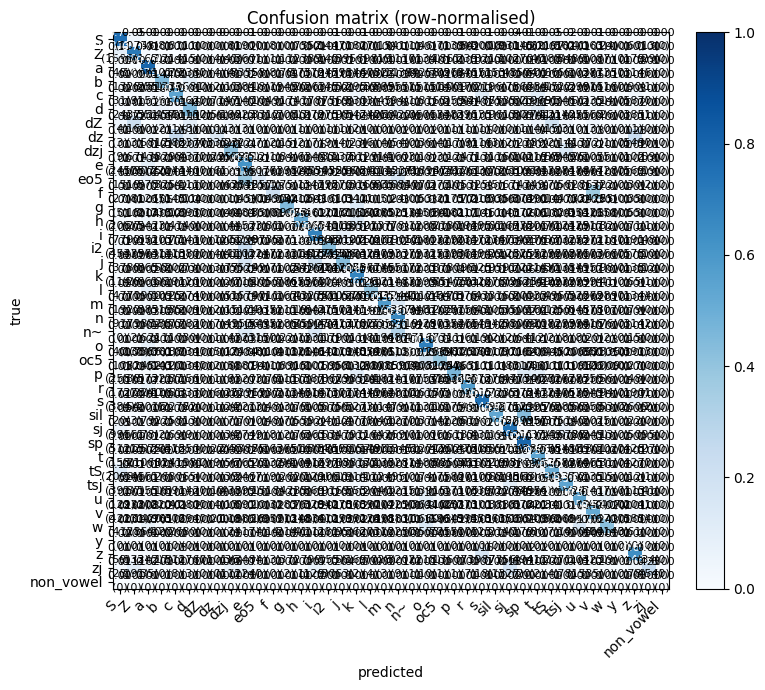


raw counts:
                   S         Z         a         b         c         d        dZ        dz       dzj         e       eo5         f         g         h         i        i2         j         k         l         m         n        n~         o       oc5         p         r         s       sil        sj        sp         t        tS       tsj         u         v         w         y         z        zj non_vowel
         S     18134      1074        58         8        81        11         0         0         8       190         0         8         0        75        52       144         7       182         7        15        41         1        46         7       139        84       300        18       931       145        62      1197       362        41       163        24         0        60        13         0
         Z      1598     10827       162        12        14        15         0         4        41       360         1         1        11        23        89     

In [9]:
import matplotlib.pyplot as plt

# accumulate confusion matrix over the validation set
cm = torch.zeros(N_CLASSES, N_CLASSES, dtype=torch.long)
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(1)
        for t, p in zip(y.cpu(), pred.cpu()):
            cm[t.item(), p.item()] += 1

# row-normalise (per true class); rows with zero support stay at 0
row_sums = cm.sum(dim=1, keepdim=True).clamp(min=1)
cm_norm  = cm.float() / row_sums

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm.numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(LABELS)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Confusion matrix (row-normalised)')

# annotate each cell: percentage + raw count
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        val   = cm_norm[i, j].item()
        count = cm[i, j].item()
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}\n({count})', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# also print raw counts as a table
print('\nraw counts:')
header = ' ' * 11 + ' '.join(f'{l:>9}' for l in LABELS)
print(header)
for i, l in enumerate(LABELS):
    row = ' '.join(f'{cm[i, j].item():>9d}' for j in range(N_CLASSES))
    print(f'{l:>10} {row}')

In [10]:
import json

CHECKPOINT_PATH = '4epoki_maly_model.pt'

# --- save ---
torch.save({
    'model_state_dict': model.state_dict(),
    'labels':           LABELS,
    'config': {
        'sample_rate': SAMPLE_RATE,
        'n_fft':       N_FFT,
        'hop_length':  HOP_LENGTH,
        'n_mels':      N_MELS,
        'win_frames':  WIN_FRAMES,
        'shift_frames': SHIFT_FRAMES,
        'hidden':      64,
    },
}, CHECKPOINT_PATH)
print(f'saved to {CHECKPOINT_PATH}')

saved to 4epoki_maly_model.pt


In [19]:
def evaluate_audio(wav_path, textgrid_path=None, model=model, device=device,
                   collapse=True, show_per_window=False, top_k=3):
    """Predict the phoneme sequence in one audio file, with probabilities.

    top_k: how many candidate phonemes to show per window (set 0 to hide).
    """
    # 1. compute mel spectrogram
    mel = wav_to_logmel(wav_path)
    n_mels, T = mel.shape
    frame_dur = HOP_LENGTH / SAMPLE_RATE

    # 2. slide windows
    windows, times = [], []
    for start in range(0, T - WIN_FRAMES + 1, SHIFT_FRAMES):
        end = start + WIN_FRAMES
        windows.append(mel[:, start:end])
        times.append((start * frame_dur, end * frame_dur))
    if not windows:
        print('audio too short for one window'); return None
    X = torch.stack(windows).to(device)

    # 3. predict + probabilities
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs  = torch.softmax(logits, dim=1).cpu()       # (W, N_CLASSES)
    pred_idx  = probs.argmax(1).tolist()
    pred      = [IDX2LABEL[i] for i in pred_idx]
    pred_prob = [probs[i, pred_idx[i]].item() for i in range(len(pred_idx))]

    # 4. optional ground truth
    truth = None
    if textgrid_path is not None:
        with open(textgrid_path, 'r', encoding='utf-8') as f:
            phonemes = parse_phonemes(f.read())
        truth = []
        for (t_start, t_end) in times:
            best, best_overlap = None, 0.0
            for (pmin, pmax, ptext) in phonemes:
                if ptext == '' or ptext not in LABEL2IDX: continue
                overlap = min(pmax, t_end) - max(pmin, t_start)
                if overlap > best_overlap:
                    best_overlap, best = overlap, ptext
            truth.append(best if best is not None else '?')

    # 5. print
    print(f'\nfile: {wav_path}')
    print(f'duration: {T*frame_dur:.2f}s, {len(pred)} windows')

    if show_per_window:
        print('\nper-window predictions:')
        header = f'{"start":>6} {"end":>6}  {"pred":>6} {"p":>5}'
        if top_k > 1:
            header += f'   top-{top_k}'
        if truth is not None:
            header += '   truth'
        print(header)

        for i, (t0, t1) in enumerate(times):
            row = f'{t0:>6.2f} {t1:>6.2f}  {pred[i]:>6} {pred_prob[i]:>5.2f}'

            if top_k > 1:
                # top-k candidates: 'a:0.62 e:0.18 o:0.09'
                topv, topi = probs[i].topk(top_k)
                cand = ' '.join(f'{IDX2LABEL[j.item()]}:{v.item():.2f}'
                                for v, j in zip(topv, topi))
                row += f'   {cand}'

            if truth is not None:
                # also show probability the model gave to the *true* class
                t_idx = LABEL2IDX[truth[i]] if truth[i] in LABEL2IDX else None
                t_p   = probs[i, t_idx].item() if t_idx is not None else float('nan')
                mark  = '✓' if pred[i] == truth[i] else '✗'
                row += f'   {truth[i]}({t_p:.2f}) {mark}'

            print(row)

    # 6. collapse runs, with avg probability per run
    def runs_with_prob(seq, ps):
        out = []
        for s, p in zip(seq, ps):
            if not out or out[-1][0] != s:
                out.append([s, [p]])
            else:
                out[-1][1].append(p)
        # convert list of probs to (count, mean_prob)
        return [(s, len(ps_), sum(ps_) / len(ps_)) for s, ps_ in out]

    if collapse:
        pr = runs_with_prob(pred, pred_prob)
        print('\npredicted phoneme sequence (count, avg prob):')
        print('  ' + ' '.join(f'{p}({n},{avg:.2f})' for p, n, avg in pr))

    # 7. accuracy + average confidence
    avg_conf = sum(pred_prob) / len(pred_prob)
    print(f'\naverage confidence on predicted class: {avg_conf:.3f}')

    if truth is not None:
        correct = sum(p == t for p, t in zip(pred, truth))
        acc = correct / len(pred)
        print(f'window-level accuracy: {correct}/{len(pred)} = {acc:.3f}')
        return {'pred': pred, 'pred_prob': pred_prob,
                'probs': probs.numpy(), 'truth': truth,
                'times': times, 'accuracy': acc}

    return {'pred': pred, 'pred_prob': pred_prob,
            'probs': probs.numpy(), 'times': times}

In [21]:
evaluate_audio('../data/501-1000/100/100000_2003.wav', '../data/501-1000/100/100000_2003.TextGrid', show_per_window=True, top_k=3)


file: ../data/501-1000/100/100000_2003.wav
duration: 11.01s, 1097 windows

per-window predictions:
 start    end    pred     p   top-3   truth
  0.00   0.05     sil  1.00   sil:1.00 sp:0.00 t:0.00   sil(1.00) ✓
  0.01   0.06     sil  0.98   sil:0.98 sp:0.02 p:0.00   sil(0.98) ✓
  0.02   0.07     sil  1.00   sil:1.00 sp:0.00 p:0.00   sil(1.00) ✓
  0.03   0.08     sil  0.98   sil:0.98 sp:0.02 v:0.00   sil(0.98) ✓
  0.04   0.09     sil  0.99   sil:0.99 sp:0.01 v:0.00   sil(0.99) ✓
  0.05   0.10     sil  0.96   sil:0.96 sp:0.02 p:0.00   sil(0.96) ✓
  0.06   0.11     sil  0.95   sil:0.95 sp:0.03 p:0.01   sil(0.95) ✓
  0.07   0.12     sil  0.95   sil:0.95 sp:0.03 p:0.01   sil(0.95) ✓
  0.08   0.13     sil  0.95   sil:0.95 sp:0.02 p:0.01   sil(0.95) ✓
  0.09   0.14     sil  0.31   sil:0.31 k:0.28 p:0.23   sil(0.31) ✓
  0.10   0.15     sil  0.37   sil:0.37 p:0.34 b:0.11   sil(0.37) ✓
  0.11   0.16     sil  0.41   sil:0.41 sp:0.27 p:0.08   sil(0.41) ✓
  0.12   0.17     sil  0.73   sil:0.73 sp:

{'pred': ['sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'k',
  't',
  't',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sil',
  'sp',
  'sp',
  'sp',
  'sil',
  'sil',
  'sil',
  'sp',
  'sp',
  'sp',
  'p',
  'p',
  'p',
  'p',
  'o',
  'o',
  'o',
  'o',
  'o',
  'n',
  'j',
  'j',
  'j',
  'i',
  'i',
  'i',
  'a',
  'a',
  'a',
  'v',
  'v',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'S',
  'S',
  'S',
  'S',
  'sj',
  'sj',
  'S',
  's',
  's',
  's',
  's',
  't',
  't',
  't',
  't',
  't',
  't',
  'k',
  't',
  't',
  't',
  'e',
  'e',
  'i2',
  'e',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a',
  'a